# Segment Customers of Azerbaijani Retail Chains Using Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "2019-Oct.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mkechinov/ecommerce-behavior-data-from-multi-category-store",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'ecommerce-behavior-data-from-multi-category-store' dataset.


In [3]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 13.9 GB


In [4]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [5]:
df.groupby('user_id').size().describe()

,0
count,3.022290e+06
mean,1.404523e+01
std,3.277411e+01
min,1.000000e+00
25%,2.000000e+00
50%,4.000000e+00
75%,1.300000e+01
max,7.436000e+03


In [11]:
trx_per_user = df.groupby('user_id').size()

qualified_users = trx_per_user[trx_per_user >= 3].index

selected_users = pd.Series(qualified_users).sample(100_000, random_state=42)

df = df[df['user_id'].isin(selected_users)].reset_index(drop=True)
df = df.dropna().reset_index(drop=True)


In [18]:
df["user_id"].nunique()

84514

In [19]:
df.shape

(1306302, 9)

In [14]:
df.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,0
brand,0
price,0
user_id,0
user_session,0


In [15]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1307539 entries, 0 to 1307538
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   event_time     1307539 non-null  object 
 1   event_type     1307539 non-null  object 
 2   product_id     1307539 non-null  int64  
 3   category_id    1307539 non-null  int64  
 4   category_code  1307539 non-null  object 
 5   brand          1307539 non-null  object 
 6   price          1307539 non-null  float64
 7   user_id        1307539 non-null  int64  
 8   user_session   1307539 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 459.4 MB


In [16]:
df['event_time']=pd.to_datetime(df['event_time'])

In [17]:
df.drop_duplicates(inplace=True)

In [20]:
df.describe()

,product_id,category_id,price,user_id
count,1.306302e+06,1.306302e+06,1.306302e+06,1.306302e+06
mean,5.335032e+06,2.055757e+18,3.491258e+02,5.337306e+08
std,8.288760e+06,1.583339e+16,3.792668e+02,1.848910e+07
min,1.000978e+06,2.053014e+18,8.800000e-01,2.692532e+08
25%,1.004856e+06,2.053014e+18,1.074900e+02,5.159766e+08
50%,1.701432e+06,2.053014e+18,2.151300e+02,5.300810e+08
75%,5.100337e+06,2.053014e+18,4.434800e+02,5.518080e+08
max,6.050001e+07,2.173217e+18,2.574070e+03,5.662795e+08


In [21]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:28+00:00,view,28714755,2053013565228450757,apparel.shoes,respect,51.22,555447570,99877fbe-d5a8-475e-a662-66bc9d29b6f8
1,2019-10-01 00:00:35+00:00,view,3601505,2053013563810775923,appliances.kitchen.washer,samsung,463.15,526631741,5ec9bd77-beef-443e-b987-62ffb55b8132
2,2019-10-01 00:00:36+00:00,view,2900475,2053013554776244595,appliances.kitchen.microwave,gorenje,295.99,533078094,6eaaf55a-7bbe-4b3d-95a8-f3b3e31c39c8
3,2019-10-01 00:00:50+00:00,view,1307135,2053013558920217191,computers.notebook,hp,320.35,542378517,244570b9-ebb4-4d4a-b63a-653225d975d5
4,2019-10-01 00:01:06+00:00,view,1307004,2053013558920217191,computers.notebook,lenovo,290.61,542378517,244570b9-ebb4-4d4a-b63a-653225d975d5


In [22]:
df.event_type.value_counts()

,count
event_type,
view,1238386
cart,39799
purchase,28117


In [23]:
df.category_code.value_counts()

,count
category_code,
electronics.smartphone,556822
computers.notebook,57151
electronics.clocks,55195
electronics.video.tv,54558
electronics.audio.headphone,53815
...,...
apparel.belt,14
auto.accessories.anti_freeze,14
construction.tools.soldering,13


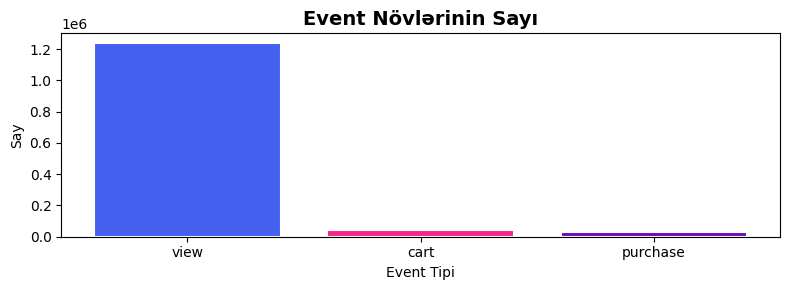

In [41]:
#Event növlərinin paylanması
event_counts = df['event_type'].value_counts()

fig, axe = plt.subplots(figsize=(8, 3))

colors = ['#4361ee', '#f72585', '#7209b7']

axe.bar(event_counts.index, event_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axe.set_title('Event Növlərinin Sayı', fontsize=14, fontweight='bold')
axe.set_xlabel('Event Tipi')
axe.set_ylabel('Say')

plt.tight_layout()
plt.show()

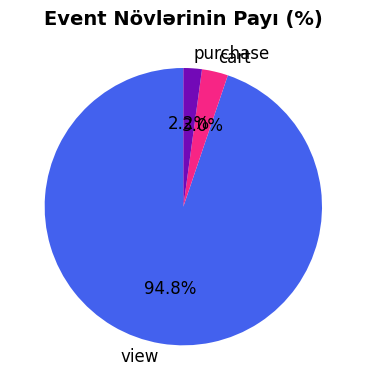

In [40]:
fig, axe = plt.subplots(figsize=(4, 4))
colors = ['#4361ee', '#f72585', '#7209b7']


axe.pie(event_counts, labels=event_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axe.set_title('Event Növlərinin Payı (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [44]:
#Konversiya nisbeti
views     = event_counts.get('view', 1)
purchases = event_counts.get('purchase', 0)
print(f'{purchases/views*100:.2f}%')

2.27%


In [45]:
top_brands = (
    df[df['event_type'] == 'purchase']
    .groupby('brand')['price']
    .agg(['count', 'sum'])
    .rename(columns={'count':'alış_sayı', 'sum':'ümumi_gəlir'})
    .sort_values('alış_sayı', ascending=False)
    .head(10)
    .reset_index()
)

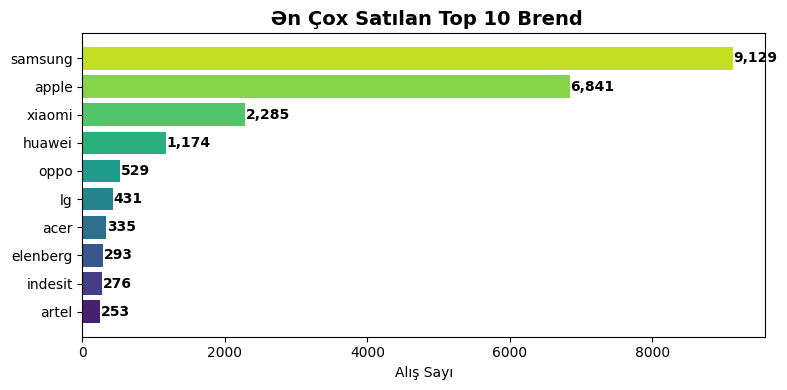

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top_brands['brand'][::-1], top_brands['alış_sayı'][::-1],color=sns.color_palette('viridis', 10))
ax.set_title(' Ən Çox Satılan Top 10 Brend', fontsize=14, fontweight='bold')
ax.set_xlabel('Alış Sayı')
for bar, val in zip(bars, top_brands['alış_sayı'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

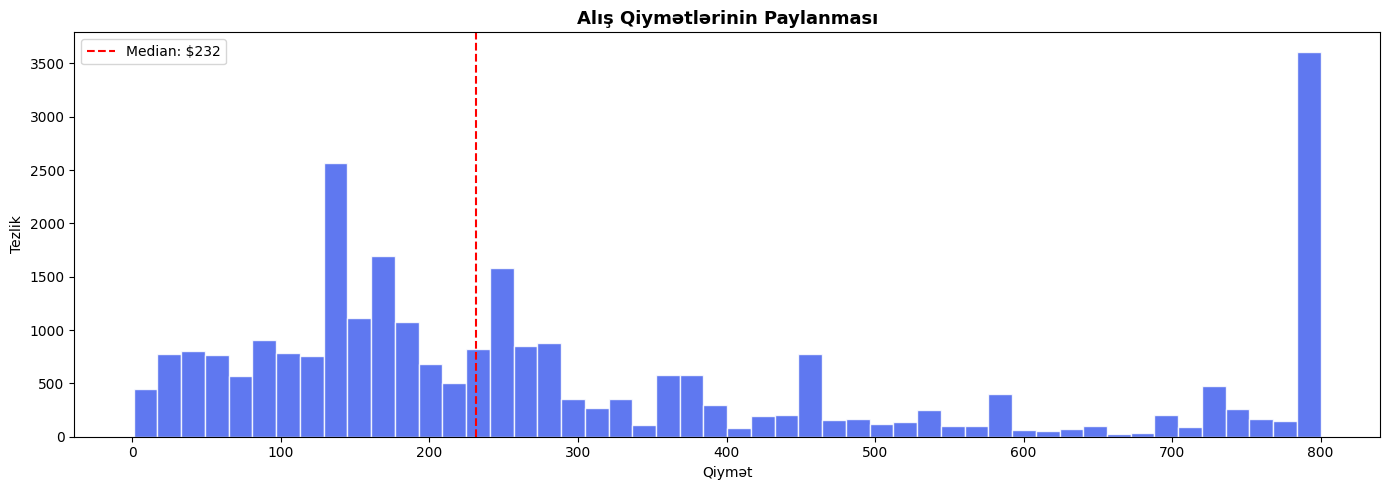

In [49]:
#Qiymət paylanması (purchase eventləri)
purchases_df = df[df['event_type'] == 'purchase'].copy()

fig, axe = plt.subplots(figsize=(14,5))
axe.hist(purchases_df['price'].clip(0, 800), bins=50, color='#4361ee', edgecolor='white', alpha=0.85)

axe.set_title('Alış Qiymətlərinin Paylanması', fontsize=13, fontweight='bold')
axe.set_xlabel('Qiymət')
axe.set_ylabel('Tezlik')
axe.axvline(purchases_df['price'].median(), color='red', linestyle='--', label=f"Median: ${purchases_df['price'].median():.0f}")
axe.legend()

plt.tight_layout()
plt.show()

In [50]:
purch = df[df['event_type'] == 'purchase'].copy()

analysis_date = purch['event_time'].max() + pd.Timedelta(days=1)
analysis_date.date()

datetime.date(2019, 11, 1)

In [57]:
rfm = purch.groupby('user_id').agg(
    recency   = ('event_time',  lambda x: (analysis_date - x.max()).days),
    frequency = ('product_id',  'count'),
    monetary  = ('price',       'sum')).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)


In [58]:
len(rfm) #unikal musteriler

13179

In [59]:
rfm[['recency','frequency','monetary']].describe().round(2)

,recency,frequency,monetary
count,13179.00,13179.00,13179.00
mean,14.77,2.13,784.76
std,8.76,4.43,2677.02
min,1.00,1.00,1.13
25%,7.00,1.00,146.78
50%,14.00,1.00,288.04
75%,22.00,2.00,742.52
max,31.00,288.00,187128.93


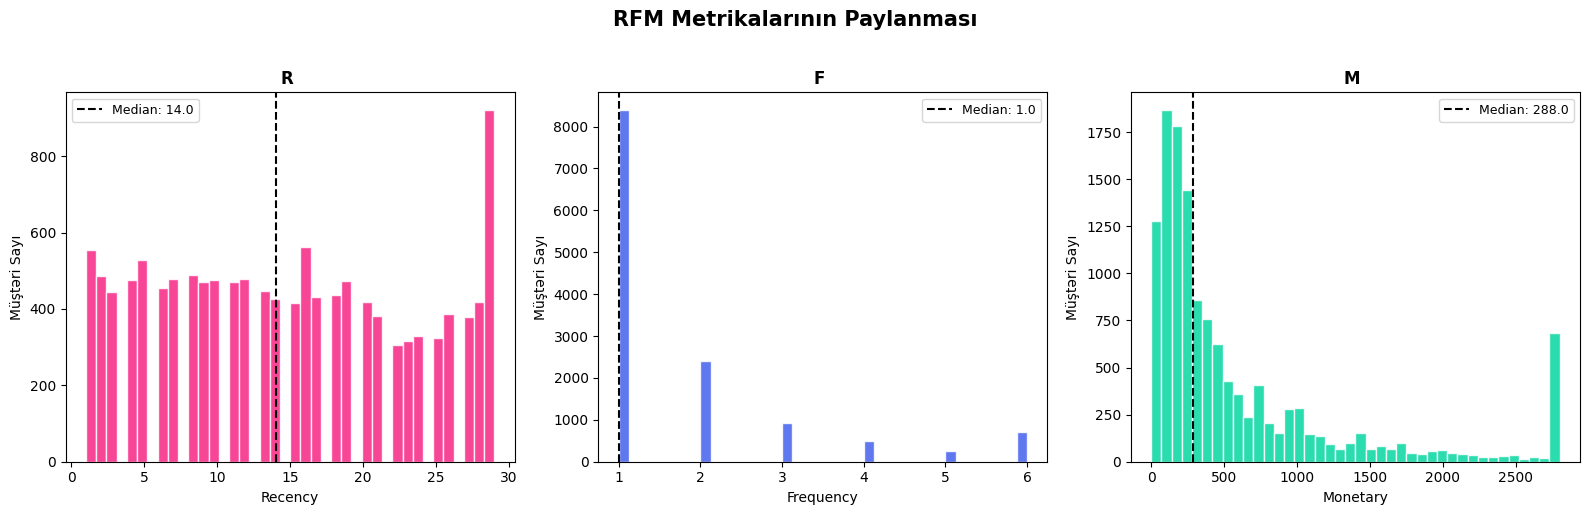

In [60]:
# RFM paylanmasını vizuallaşdırırıq
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [('recency',   'R ',       '#f72585'),
    ('frequency', 'F ','#4361ee'),
    ('monetary',  'M ',         '#06d6a0')]

for ax, (col, title, color) in zip(axes, metrics):
    clip_val = rfm[col].quantile(0.95)
    ax.hist(rfm[col].clip(0, clip_val), bins=40, color=color, edgecolor='white', alpha=0.85)

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Müştəri Sayı')
    ax.axvline(rfm[col].median(), color='black', linestyle='--', linewidth=1.5,label=f'Median: {rfm[col].median():.1f}')
    ax.legend(fontsize=9)

plt.suptitle('RFM Metrikalarının Paylanması', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##Feature Engineering Normallaşdırma

In [61]:
# Log transform paylanmanı düzəldirik (xüsusilə monetary)
rfm['log_recency']   = np.log1p(rfm['recency'])
rfm['log_frequency'] = np.log1p(rfm['frequency'])
rfm['log_monetary']  = np.log1p(rfm['monetary'])

features = ['log_recency', 'log_frequency', 'log_monetary']

In [63]:
from sklearn.preprocessing import StandardScaler
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(rfm[features])
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

In [64]:
X_scaled_df.describe().round(3)

,log_recency,log_frequency,log_monetary
count,13179.000,13179.000,13179.000
mean,0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-2.513,-0.579,-4.022
25%,-0.629,-0.579,-0.636
50%,0.226,-0.579,-0.100
75%,0.807,0.287,0.654
max,1.256,10.037,5.070


## Optimal Klaster Sayını Tapırıq — Elbow + Silhouette
**Elbow metodu:** WCSS (daxili dispersiya) klaster sayı artdıqca azalır — dirsək nöqtəsi optimaldır.

In [65]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
wcss        = []
sil_scores  = []
K_range     = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=5000))
    print(f'  k={k}  WCSS: {km.inertia_:.0f} | Silhouette: {sil_scores[-1]:.3f}')

  k=2  WCSS: 25404 | Silhouette: 0.425
  k=3  WCSS: 18552 | Silhouette: 0.358
  k=4  WCSS: 14499 | Silhouette: 0.321
  k=5  WCSS: 12509 | Silhouette: 0.283
  k=6  WCSS: 11040 | Silhouette: 0.283
  k=7  WCSS: 9852 | Silhouette: 0.297
  k=8  WCSS: 8792 | Silhouette: 0.300
  k=9  WCSS: 8034 | Silhouette: 0.309
  k=10  WCSS: 7370 | Silhouette: 0.322


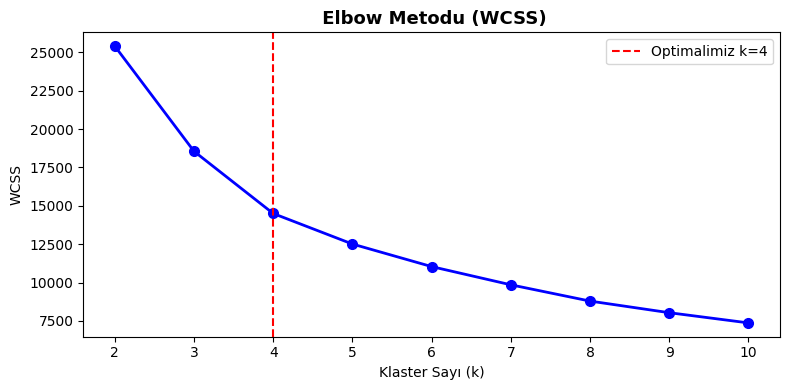

In [73]:
fig, axe= plt.subplots( figsize=(8, 4))

axe.plot(K_range, wcss, 'bo-', linewidth=2, markersize=7)
axe.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Optimalimiz k=4')
axe.set_title(' Elbow Metodu (WCSS)', fontsize=13, fontweight='bold')
axe.set_xlabel('Klaster Sayı (k)')
axe.set_ylabel('WCSS')
axe.legend()
plt.tight_layout()
plt.show()

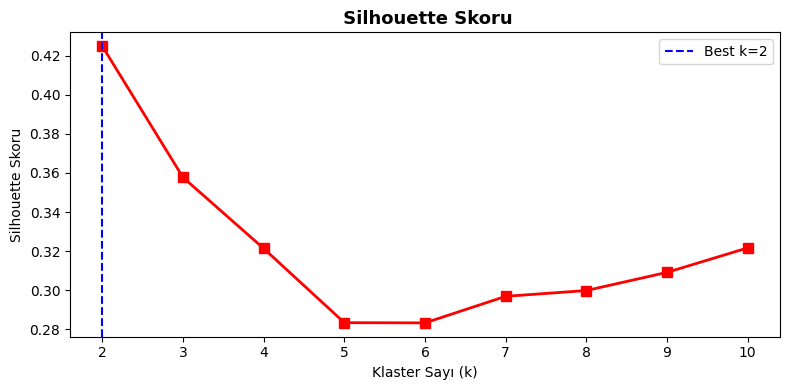

In [74]:
fig, axe= plt.subplots( figsize=(8, 4))
axe.plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=7)

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
axe.axvline(x=best_k, color='blue', linestyle='--', linewidth=1.5, label=f'Best k={best_k}')

axe.set_title(' Silhouette Skoru', fontsize=13, fontweight='bold')
axe.set_xlabel('Klaster Sayı (k)')
axe.set_ylabel('Silhouette Skoru')
axe.legend()

plt.tight_layout()
plt.show()


##K-Means Model — k=4 ilə
Elbow + Silhouette analizi + məntiqinə əsasən **4 klaster** seçek.

In [76]:
K =4

kmeans = KMeans(
    n_clusters = K,
    random_state = 42,
    n_init = 15,
    max_iter = 500)

rfm['cluster'] = kmeans.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, rfm['cluster'], sample_size=8000)

In [80]:
final_sil

np.float64(0.3207538917497553)

In [81]:
rfm['cluster'].value_counts().sort_index()

,count
cluster,
0,5206
1,1285
2,2721
3,3967


##Klaster Profilləri
Hər klasterin RFM ortalamalarına baxırıq — bu bizə klasterin şəxsiyyətini verir.

In [82]:

cluster_profile = rfm.groupby('cluster').agg(
    müştəri_sayı = ('user_id',    'count'),
    ort_recency  = ('recency',    'mean'),
    ort_frequency= ('frequency',  'mean'),
    ort_monetary = ('monetary',   'mean'),
    max_monetary = ('monetary',   'max')
).round(2)

cluster_profile['pay_%'] = (cluster_profile['müştəri_sayı'] / cluster_profile['müştəri_sayı'].sum() * 100).round(1)


In [83]:
cluster_profile

,müştəri_sayı,ort_recency,ort_frequency,ort_monetary,max_monetary,pay_%
cluster,,,,,,
0,5206,19.44,1.08,158.04,391.00,39.5
1,1285,8.13,8.80,3861.38,187128.93,9.8
2,2721,4.19,1.38,383.52,4063.40,20.6
3,3967,18.04,1.87,885.85,5369.46,30.1


### Klasterlərə ad veririk profil əsasında RFM dəyərlərinə baxaraq manual seçirik

In [88]:
segment_map = {
    0: 'Passiv Qənaətcil',       # köhnə, az, ucuz
    1: 'Sadiq Yüksək Dəyərli',  # recent, tez-tez, çox pul
    2: 'Yeni Yüksək Potensial',  # çox yeni, az alış amma orta-yüksək məbləğ
    3: 'Riskdə Olan Dəyərli'     # köhnədir ama baha alıb
}

cluster_profile['seqment_adı'] = cluster_profile.index.map(segment_map)
rfm['segment'] = rfm['cluster'].map(segment_map)


In [89]:
cluster_profile[['müştəri_sayı','pay_%','ort_recency','ort_frequency','ort_monetary','seqment_adı']]

,müştəri_sayı,pay_%,ort_recency,ort_frequency,ort_monetary,seqment_adı
cluster,,,,,,
0,5206,39.5,19.44,1.08,158.04,Passiv Qənaətcil
1,1285,9.8,8.13,8.80,3861.38,Sadiq Yüksək Dəyərli
2,2721,20.6,4.19,1.38,383.52,Yeni Yüksək Potensial
3,3967,30.1,18.04,1.87,885.85,Riskdə Olan Dəyərli


##Vizualizasiya — PCA ilə 2D Klaster Görüntüsü
3 dimension-u 2-yə endiririk (PCA) ki, klasterlər qrafikdə görünsün.

In [90]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

rfm['pca1'] = X_pca[:, 0]
rfm['pca2'] = X_pca[:, 1]

explained = pca.explained_variance_ratio_ * 100

In [91]:
print(f'PCA dispersiyasi: {explained[0]:.1f}% + {explained[1]:.1f}% = {sum(explained):.1f}%')

PCA dispersiyasi: 57.2% + 30.3% = 87.5%


In [93]:
fig = px.scatter(
    rfm.sample(min(8000, len(rfm)), random_state=42),
    x='pca1', y='pca2',
    color='segment',
    hover_data=['recency','frequency','monetary'],
    title='Seqmentlərin PCA Xəritəsi',
    labels={'pca1': f'PCA 1 ({explained[0]:.1f}%)',
            'pca2': f'PCA 2 ({explained[1]:.1f}%)'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.6,
    width=900, height=450)
fig.update_traces(marker=dict(size=5))
fig.update_layout(legend_title='Seqment', font=dict(size=12))
fig.show()

Passiv Qənaətcil (mavi) ilə Riskdə Olan Dəyərli (bənövşəyi) birbirinə çox yapışıb bu o deməkdir ki bu iki seqment PCAda çətin ayrılır, amma RFM rəqəmlərində fərqləri var (monetary: 158 885).

In [96]:
# Seqment paylanması Sunburst
seg_dist = rfm['segment'].value_counts().reset_index()
seg_dist.columns = ['segment','count']

fig = px.pie(
    seg_dist,
    values='count',
    names='segment',
    title=' Seqmentlərə Görə Müştəri Paylanması',
    color_discrete_sequence=px.colors.qualitative.Bold,
    hole=0.35)
fig.update_traces(textposition='outside', textinfo='percent+label')
fig.update_layout(width=650, height=280, showlegend=False)
fig.show()

In [99]:
#RFM Scatter Matrix seqmentlər üzrə
sample_rfm = rfm.sample(min(6000, len(rfm)), random_state=42)

fig = px.scatter_matrix(
    sample_rfm,
    dimensions=['recency','frequency','monetary'],
    color='segment',
    title='RFM Scatter Matrix',
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.5,
    width=800, height=600)
fig.update_traces(marker=dict(size=3))
fig.show()

##DBSCAN
Avtomatik klaster sayını tapır, amma sparse data ilə çətin olur.Sinayaq

In [104]:
dbscan = DBSCAN(eps=0.5, min_samples=30, n_jobs=-1)
db_labels = dbscan.fit_predict(X_scaled)

In [106]:
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_clusters_db

6

In [107]:
n_noise = (db_labels == -1).sum()
n_noise

np.int64(557)

In [105]:
noise_pct     = n_noise / len(db_labels) * 100
noise_pct

np.float64(4.226420821003111)

In [109]:
if n_clusters_db >= 2:
    db_sil = silhouette_score(X_scaled[db_labels != -1],
                              db_labels[db_labels != -1],
                              sample_size=5000)
    print(f'{db_sil:.4f}')
    print(f'{final_sil:.4f}')
    print(f'Bu datasette K-Means daha yaxşidi')
else:
    print('DBSCAN bu parametrlərlə yaxşı klaster tapa bilmir')
    '''   eps və min_samples-i dəyişdirmek olar amma K-Means bu data üçün daha uygundu'''

0.1457
0.3208
Bu datasette K-Means daha yaxşidi
